#Model 4: playBERThwatt
With
- Asymmetric loss
- Threshold per label
- Head wise attention
- XAI attention output

# 0.0 Dependencies

## 0.1 Installs

In [ ]:
#Install needed package
#For stratification
!pip install iterative-stratification
#For datasets
!pip install -q datasets
#For using trainer
!pip install -U transformers
#For F1 and precision-k usage
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 129.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 60.0 MB/s eta 0:00:00


## 0.2 Imports

In [ ]:
#Core data
import pandas as pd
import numpy as np

#Sklearn
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score

#Multilabel stratification
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

#Pytorch
import torch
import torch.nn as nn

#Huggingface
from transformers import AutoTokenizer, AutoModel
from transformers import TrainingArguments, Trainer
from transformers import EarlyStoppingCallback
from datasets import Dataset

#Plots
import matplotlib.pyplot as plt

#For evaluation metrics
from torchmetrics.classification import MultilabelF1Score, MultilabelPrecision, MultilabelRecall
from sklearn.metrics import label_ranking_average_precision_score
from torch.utils.data import DataLoader
from IPython.display import display


# 1.0 Dataprep

## 1.1 Load data and relevant columns

In [ ]:
# Load CSV
df = pd.read_csv("tv2_data_cutoffs.csv")

df = df[
    ["Titel", "Genre", "Genre_p", "Form", "Form_p", "Målgruppe", "Målgruppe_p",
     "Emne", "Emne_p", "Stemning", "Stemning_p", "Play description"]]

print(f"Number of rows: {len(df)}")
print(df.head())


Number of rows: 2153
                   Titel                             Genre        Genre_p  \
0  1 døgn, 2 hold, 3 dyr         Dokumentar, Underholdning  Underholdning   
1      1-0 til fremtiden  Livsstil, Dokumentar, Aktualitet     Dokumentar   
2        100 kilo senere                          Livsstil       Livsstil   
3              100% sjov                     Underholdning  Underholdning   
4             12 Monkeys        Drama, Adventure, Thriller      Adventure   

                                Form       Form_p        Målgruppe  \
0  Konkurrence, Iscenesat, Reportage  Konkurrence  Familie, 15+ år   
1                 Portræt, Reportage    Reportage           15+ år   
2                          Iscenesat    Iscenesat           15+ år   
3                  Konkurrence, Show  Konkurrence  Familie, 15+ år   
4                              Serie        Serie           15+ år   

  Målgruppe_p                                               Emne     Emne_p  \
0     Familie  D

## 1.2 Data split (stratification)

In [ ]:
LABEL_COLS = ["Genre", "Form", "Målgruppe", "Emne", "Stemning"]

all_labels = []

for _, row in df.iterrows():
    labels = []

    for col in LABEL_COLS:
        value = row[col]
        if pd.notna(value):
            for label in value.split(","):
                labels.append(label.strip())

    all_labels.append(labels)

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(all_labels)

In [ ]:
#Stratification 70/30 (train and temp)
X = df.index.values

stratsplit = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.30, random_state=4
)
train_idx, temp_idx = next(stratsplit.split(X, Y))

df_train = df.iloc[train_idx]
df_temp  = df.iloc[temp_idx]
Y_temp   = Y[temp_idx]

#Stratification 15/15 (val and test)
stratsplit2 = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.50, random_state=4
)

val_idx, test_idx = next(stratsplit2.split(df_temp.index.values, Y_temp))

df_val  = df_temp.iloc[val_idx]
df_test = df_temp.iloc[test_idx]

## 1.3 Target encoding (binarization)

In [ ]:
#split label function for binarization
def split_labels(series):
    labels = []

    for value in series.fillna(""):
        parts = []
        for label in value.split(","):
            label = label.strip()
            if label:
                parts.append(label)
        labels.append(parts)

    return labels

#Binarization of all categories
#Genre
mlb_genre = MultiLabelBinarizer()
mlb_genre.fit(split_labels(df["Genre"]))
y_train_genre = mlb_genre.transform(split_labels(df_train["Genre"]))
y_val_genre   = mlb_genre.transform(split_labels(df_val["Genre"]))
y_test_genre  = mlb_genre.transform(split_labels(df_test["Genre"]))

print(f"Genre labels: {len(mlb_genre.classes_)}")

#Form
mlb_form = MultiLabelBinarizer()
mlb_form.fit(split_labels(df["Form"]))
y_train_form = mlb_form.transform(split_labels(df_train["Form"]))
y_val_form   = mlb_form.transform(split_labels(df_val["Form"]))
y_test_form  = mlb_form.transform(split_labels(df_test["Form"]))

print(f"Form labels: {len(mlb_form.classes_)}")

#Målgruppe
mlb_maalgruppe = MultiLabelBinarizer()
mlb_maalgruppe.fit(split_labels(df["Målgruppe"]))
y_train_maalgruppe = mlb_maalgruppe.transform(split_labels(df_train["Målgruppe"]))
y_val_maalgruppe   = mlb_maalgruppe.transform(split_labels(df_val["Målgruppe"]))
y_test_maalgruppe  = mlb_maalgruppe.transform(split_labels(df_test["Målgruppe"]))

print(f"Målgruppe labels: {len(mlb_maalgruppe.classes_)}")

#Emne
mlb_emne = MultiLabelBinarizer()
mlb_emne.fit(split_labels(df["Emne"]))
y_train_emne = mlb_emne.transform(split_labels(df_train["Emne"]))
y_val_emne   = mlb_emne.transform(split_labels(df_val["Emne"]))
y_test_emne  = mlb_emne.transform(split_labels(df_test["Emne"]))

print(f"Emne labels: {len(mlb_emne.classes_)}")

#Stemning
mlb_stemning = MultiLabelBinarizer()
mlb_stemning.fit(split_labels(df["Stemning"]))
y_train_stemning = mlb_stemning.transform(split_labels(df_train["Stemning"]))
y_val_stemning   = mlb_stemning.transform(split_labels(df_val["Stemning"]))
y_test_stemning  = mlb_stemning.transform(split_labels(df_test["Stemning"]))

print(f"Stemning labels: {len(mlb_stemning.classes_)}")


Genre labels: 10
Form labels: 10
Målgruppe labels: 6
Emne labels: 97
Stemning labels: 25


In [ ]:
# Check if stratification worked (70/15/15 distribution)
# Emne category is used as an example
train_counts = y_train_emne.sum(axis=0)
val_counts = y_val_emne.sum(axis=0)
test_counts = y_test_emne.sum(axis=0)
total_counts = train_counts + val_counts + test_counts

# Calculate percentage of total for each split
train_dist = (train_counts / total_counts) * 100
val_dist = (val_counts / total_counts) * 100
test_dist = (test_counts / total_counts) * 100

#check on emne class due to its size
df_check = pd.DataFrame({
    "Label": mlb_emne.classes_,
    "Total Count": total_counts,
    "Train Count": train_counts,
    "Val Count": val_counts,
    "Test Count": test_counts,
    "Train distribution (%)": train_dist,
    "Val distribution (%)": val_dist,
    "Test distribution (%)": test_dist
})

display(df_check.round(1))

,Label,Total Count,Train Count,Val Count,Test Count,Train distribution (%),Val distribution (%),Test distribution (%)
0,Arbejdsliv,196,137,28,31,69.9,14.3,15.8
1,Barndom,39,27,6,6,69.2,15.4,15.4
2,Bedrag,52,36,8,8,69.2,15.4,15.4
3,Beredskab,31,22,4,5,71.0,12.9,16.1
4,Bolig,107,75,16,16,70.1,15.0,15.0
...,...,...,...,...,...,...,...,...
92,Venskab,317,224,46,47,70.7,14.5,14.8
93,Videnskab,37,26,5,6,70.3,13.5,16.2
94,Voksenliv,30,21,4,5,70.0,13.3,16.7
95,Ægteskab,41,29,6,6,70.7,14.6,14.6


## 1.4 Tokenization and dataset creation

In [ ]:
MODEL_NAME = "BSC-LT/MrBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/19.1M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.81M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

In [ ]:
#Find fitting tokenlength
encodings = tokenizer(
    df_train["Play description"].tolist(),
    add_special_tokens=True,
    truncation=False,
    padding=False
    )

token_lengths = []
for ids in encodings["input_ids"]:
    token_lengths.append(len(ids))

token_lengths = np.array(token_lengths)

print(f"Number of texts: {len(token_lengths)}")
print(f"Median: {np.percentile(token_lengths, 50)}")
print(f"95%: {np.percentile(token_lengths, 95)}")
print(f"99%: {np.percentile(token_lengths, 99)}")
print(f"Max: {token_lengths.max()}")


Number of texts: 1502
Median: 45.0
95%: 79.0
99%: 105.99000000000001
Max: 159


In [ ]:
#then setting the max length
#includes longest text and avoid truncation
MAX_LENGTH = 159

In [ ]:
#Dataset creation
# Tokenize function
def tokenize_fn(examples):
    return tokenizer(
        examples["Play description"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

#prepare dataset
def prepare_dataset(df, y_genre, y_form, y_maalgruppe, y_emne, y_stemning):
    ds = Dataset.from_dict({
        "Play description": df["Play description"].tolist(),
        "y_genre": y_genre.astype(float).tolist(),
        "y_form": y_form.astype(float).tolist(),
        "y_maalgruppe": y_maalgruppe.astype(float).tolist(),
        "y_emne": y_emne.astype(float).tolist(),
        "y_stemning": y_stemning.astype(float).tolist()
        })

    #Apply tokenization
    ds = ds.map(tokenize_fn, batched=True)
    #Set format to torch
    cols_to_keep = ["input_ids", "attention_mask", "y_genre", "y_form", "y_maalgruppe", "y_emne", "y_stemning"]
    ds.set_format(type="torch", columns=cols_to_keep)

    return ds

train_dataset = prepare_dataset(df_train, y_train_genre, y_train_form, y_train_maalgruppe, y_train_emne, y_train_stemning)
val_dataset   = prepare_dataset(df_val, y_val_genre, y_val_form, y_val_maalgruppe, y_val_emne, y_val_stemning)
test_dataset  = prepare_dataset(df_test, y_test_genre, y_test_form, y_test_maalgruppe, y_test_emne, y_test_stemning)


Map:   0%|          | 0/1502 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Map:   0%|          | 0/339 [00:00<?, ? examples/s]

In [ ]:
#makes sure the shape match the labels
sample_dataset = train_dataset[0]

print(f"y_genre shape: {sample_dataset['y_genre'].shape}")
print(f"y_form shape: {sample_dataset['y_form'].shape}")
print(f"y_maalgruppe shape: {sample_dataset['y_maalgruppe'].shape}")
print(f"y_emne shape: {sample_dataset['y_emne'].shape}")
print(f"y_stemning shape: {sample_dataset['y_stemning'].shape}")


y_genre shape: torch.Size([10])
y_form shape: torch.Size([10])
y_maalgruppe shape: torch.Size([6])
y_emne shape: torch.Size([97])
y_stemning shape: torch.Size([25])


# 2.0 Model

## 2.1 Architecture

In [ ]:
#Loss
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8, disable_torch_grad_focal_loss=True):
        super(AsymmetricLoss, self).__init__()

        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.disable_torch_grad_focal_loss = disable_torch_grad_focal_loss
        self.eps = eps

    def forward(self, x, y):
        """"
        Parameters
        ----------
        x: input logits
        y: targets (multi-label binarized vector)
        """

        # Calculating Probabilities
        x_sigmoid = torch.sigmoid(x)
        xs_pos = x_sigmoid
        xs_neg = 1 - x_sigmoid

        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Basic CE calculation
        los_pos = y * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg

        # Asymmetric Focusing
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            if self.disable_torch_grad_focal_loss:
                torch.set_grad_enabled(False)
            pt0 = xs_pos * y
            pt1 = xs_neg * (1 - y)  # pt = p if t > 0 else 1-p
            pt = pt0 + pt1
            one_sided_gamma = self.gamma_pos * y + self.gamma_neg * (1 - y)
            one_sided_w = torch.pow(1 - pt, one_sided_gamma)
            if self.disable_torch_grad_focal_loss:
                torch.set_grad_enabled(True)
            loss *= one_sided_w

        return -loss.sum()

In [ ]:
# Additive Attention for each classification head
class HeadAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, hidden_states, attention_mask):
        #find raw attention scores and remove the last dimension
        scores = self.attention(hidden_states).squeeze(-1)

        #remove padding tokens before applying softmax
        scores = scores.masked_fill(attention_mask == 0, -10000.0)

        #Convert scores to attention weights
        weights = torch.softmax(scores, dim=-1)

        #Compute the weighted sum of hidden states
        context = torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)

        return context, weights

In [ ]:
MODEL_NAME = "BSC-LT/MrBERT"

#defining the architecture of the model
class playBERTbase(nn.Module):
    def __init__(self, n_genre, n_form, n_maalgruppe, n_emne, n_stemning):
        super().__init__()

        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        #Freeze backbone
        for param in self.bert.parameters():
            param.requires_grad = False

        hidden_size = self.bert.config.hidden_size

        # Attention layers for each head
        self.genre_attn = HeadAttention(hidden_size)
        self.form_attn = HeadAttention(hidden_size)
        self.maalgruppe_attn = HeadAttention(hidden_size)
        self.emne_attn = HeadAttention(hidden_size)
        self.stemning_attn = HeadAttention(hidden_size)

        #5 heads
        self.genre_head = nn.Linear(hidden_size, n_genre)
        self.form_head = nn.Linear(hidden_size, n_form)
        self.maalgruppe_head = nn.Linear(hidden_size, n_maalgruppe)
        self.emne_head = nn.Linear(hidden_size, n_emne)
        self.stemning_head = nn.Linear(hidden_size, n_stemning)

        #the loss function
        self.loss_fn = AsymmetricLoss()

    def forward(self, input_ids, attention_mask,
                y_genre=None, y_form=None, y_maalgruppe=None, y_emne=None, y_stemning=None):

        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state

        # Apply head-wise attention instead of just using CLS
        genre_context, genre_weights = self.genre_attn(hidden_states, attention_mask)
        form_context, form_weights = self.form_attn(hidden_states, attention_mask)
        maalgruppe_context, maalgruppe_weights = self.maalgruppe_attn(hidden_states, attention_mask)
        emne_context, emne_weights = self.emne_attn(hidden_states, attention_mask)
        stemning_context, stemning_weights = self.stemning_attn(hidden_states, attention_mask)

        genre_logits = self.genre_head(genre_context)
        form_logits = self.form_head(form_context)
        maalgruppe_logits = self.maalgruppe_head(maalgruppe_context)
        emne_logits = self.emne_head(emne_context)
        stemning_logits = self.stemning_head(stemning_context)

        logits = {
            "genre": genre_logits,
            "form": form_logits,
            "maalgruppe": maalgruppe_logits,
            "emne": emne_logits,
            "stemning": stemning_logits,
        }

        attention_weights = {
            "genre": genre_weights,
            "form": form_weights,
            "maalgruppe": maalgruppe_weights,
            "emne": emne_weights,
            "stemning": stemning_weights,
        }

        has_labels = True
        for y in [y_genre, y_form, y_maalgruppe, y_emne, y_stemning]:
            if y is None:
                has_labels = False

        if has_labels:
            loss = (
                self.loss_fn(genre_logits, y_genre)
              + self.loss_fn(form_logits, y_form)
              + self.loss_fn(maalgruppe_logits, y_maalgruppe)
              + self.loss_fn(emne_logits, y_emne)
              + self.loss_fn(stemning_logits, y_stemning)
            )
            return loss, logits, attention_weights

        return logits, attention_weights


In [ ]:
#Initialize the model
model = playBERTbase(
    n_genre=len(mlb_genre.classes_),
    n_form=len(mlb_form.classes_),
    n_maalgruppe=len(mlb_maalgruppe.classes_),
    n_emne=len(mlb_emne.classes_),
    n_stemning=len(mlb_stemning.classes_)
)

model.safetensors:   0%|          | 0.00/1.23G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: BSC-LT/MrBERT
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 2.2 Training

Epoch,Training Loss,Validation Loss
1,129.971243,112.745743
2,109.262571,111.215446
3,103.874242,109.728165
4,99.515937,109.465683
5,94.611702,109.624878
6,89.870190,110.332306
7,85.754436,113.135056
8,82.307991,113.691055
9,78.847324,116.632111


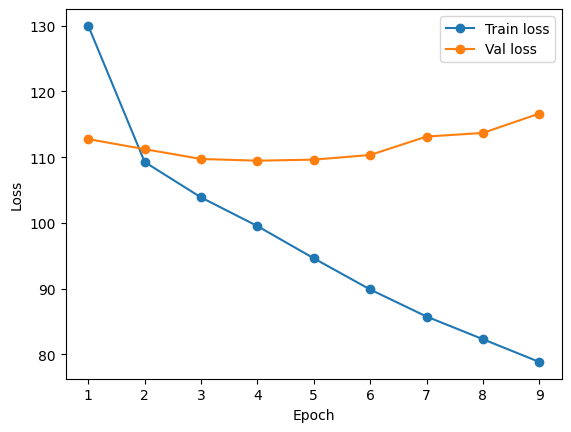

Training done. Model has been set to best iteration: ./checkpoints/checkpoint-376


In [ ]:
#setting the training arguments
training_args = TrainingArguments(
    output_dir="./checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=1e-03,
    optim="adamw_torch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=100,
    report_to="none",
    remove_unused_columns=False,
    bf16=True,
    label_names=["y_genre", "y_form", "y_maalgruppe", "y_emne", "y_stemning"]
)

#the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)
trainer.train()

#creating a loss plot to identify overfit
train_losses = []
train_epochs = []
val_losses = []
val_epochs = []

for entry in trainer.state.log_history:
    if "loss" in entry and "epoch" in entry and "eval_loss" not in entry:
        train_losses.append(entry["loss"])
        train_epochs.append(entry["epoch"])
    if "eval_loss" in entry and "epoch" in entry:
        val_losses.append(entry["eval_loss"])
        val_epochs.append(entry["epoch"])

plt.plot(train_epochs, train_losses, label="Train loss", marker="o")
plt.plot(val_epochs, val_losses, label="Val loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

print(f"Training done. Model has been set to best iteration: {trainer.state.best_model_checkpoint}")


# 3.0 Evaluation

## 3.1 Evaluation functions

In [ ]:
#Function to fetch predictions
def predictions(model, dataloader, device, label_counts):
    model.eval()

    all_true = {}
    all_probs = {}
    for head in label_counts.keys():
        all_true[head] = []
        all_probs[head] = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits, attention_weights = model(input_ids=input_ids, attention_mask=attention_mask)

            for head in label_counts.keys():
                all_probs[head].append(torch.sigmoid(logits[head]).cpu())
                all_true[head].append(batch[f"y_{head}"].cpu())

    for head in label_counts.keys():
        all_true[head] = torch.cat(all_true[head], dim=0).long()
        all_probs[head] = torch.cat(all_probs[head], dim=0)

    return all_true, all_probs

#optimal thresholds per label found from validation split
def optimal_thresholds(all_true, all_probs, label_counts):
    optimal_thresholds = {}
    for head, num_classes in label_counts.items():
        y_true = all_true[head].numpy()
        y_prob = all_probs[head].numpy()

        head_thresholds = []

        for label_idx in range(num_classes):
            label_true = y_true[:, label_idx]
            label_prob = y_prob[:, label_idx]

            best_thresh = 0.5
            best_f1 = 0.0

            for i in range(1, 100):
                thresh = i / 100.0
                y_pred = (label_prob >= thresh).astype(int)

                f1 = f1_score(label_true, y_pred, average="binary", zero_division=0)

                if f1 > best_f1:
                    best_f1 = f1
                    best_thresh = thresh

            head_thresholds.append(best_thresh)

        optimal_thresholds[head] = torch.tensor(head_thresholds)

    return optimal_thresholds

#Function to calculate F1, Precision, and Recall
def metrics(all_true, all_probs, label_counts, thresholds):
    results = []
    for head, num_classes in label_counts.items():
        th = thresholds[head]

        y_pred = (all_probs[head] >= th).int()

        #F1
        micro_f1_metric = MultilabelF1Score(num_labels=num_classes, average="micro")
        micro_f1 = micro_f1_metric(y_pred, all_true[head]).item()

        macro_f1_metric = MultilabelF1Score(num_labels=num_classes, average="macro")
        macro_f1 = macro_f1_metric(y_pred, all_true[head]).item()

        # Precision
        micro_prec_metric = MultilabelPrecision(num_labels=num_classes, average="micro")
        micro_prec = micro_prec_metric(y_pred, all_true[head]).item()

        macro_prec_metric = MultilabelPrecision(num_labels=num_classes, average="macro")
        macro_prec = macro_prec_metric(y_pred, all_true[head]).item()

        #Recall
        micro_rec_metric = MultilabelRecall(num_labels=num_classes, average="micro")
        micro_rec = micro_rec_metric(y_pred, all_true[head]).item()

        macro_rec_metric = MultilabelRecall(num_labels=num_classes, average="macro")
        macro_rec = macro_rec_metric(y_pred, all_true[head]).item()

        results.append({
            "Category": head.title(),
            "Threshold": "Label-wise",
            "Micro-F1": micro_f1,
            "Macro-F1": macro_f1,
            "Micro-Prec": micro_prec,
            "Macro-Prec": macro_prec,
            "Micro-Rec": micro_rec,
            "Macro-Rec": macro_rec
        })

    return pd.DataFrame(results)

#Function to calculate Label Ranking Average Precision (LRAP)
def lrap(all_true, all_probs, label_counts):
    results = []
    for head in label_counts.keys():
        y_true_np = all_true[head].numpy()
        y_score_np = all_probs[head].numpy()

        lrap = label_ranking_average_precision_score(y_true_np, y_score_np)

        results.append({
            "Category": head.title(),
            "LRAP": lrap
        })
    return pd.DataFrame(results)

#Function to calculate R-Precision
def r_precision(all_true, all_probs, label_counts):
    results = []
    for head in label_counts.keys():
        p_at_k_scores = []
        for i in range(len(all_true[head])):
            true_labels_vector = all_true[head][i]
            probs = all_probs[head][i]
            k = int(true_labels_vector.sum().item())

            if k > 0:
                top_k_indices = torch.topk(probs, k).indices
                correct_in_k = true_labels_vector[top_k_indices].sum().item()
                p_at_k_scores.append(correct_in_k / k)

        if len(p_at_k_scores) > 0:
            avg_p_at_k = np.mean(p_at_k_scores)
        else:
            avg_p_at_k = 0

        results.append({
            "Category": head.title(),
            "R-Precision": avg_p_at_k
        })
    return pd.DataFrame(results)


## 3.2 Evaluation on validation set

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

#dictionary for labels
label_counts = {
    "genre": len(mlb_genre.classes_),
    "form": len(mlb_form.classes_),
    "maalgruppe": len(mlb_maalgruppe.classes_),
    "emne": len(mlb_emne.classes_),
    "stemning": len(mlb_stemning.classes_)
}

# Evaluate on the Validation set
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
val_true, val_probs = predictions(model, val_loader, device, label_counts)

# Calculate optimal thresholds based on validation set
best_thresholds = optimal_thresholds(val_true, val_probs, label_counts)

# Calculate metrics with tuned thresholds
df_val_metrics = metrics(val_true, val_probs, label_counts, thresholds=best_thresholds)
df_val_lrap = lrap(val_true, val_probs, label_counts)
df_val_r_prec = r_precision(val_true, val_probs, label_counts)

# Merge the DataFrames based on the 'Category' column
val_results = pd.merge(df_val_lrap, df_val_r_prec, on="Category")
val_results = pd.merge(val_results, df_val_metrics, on="Category")

display(val_results.round(3))

,Category,LRAP,R-Precision,Threshold,Micro-F1,Macro-F1,Micro-Prec,Macro-Prec,Micro-Rec,Macro-Rec
0,Genre,0.663,0.498,Label-wise,0.545,0.504,0.448,0.429,0.695,0.637
1,Form,0.635,0.483,Label-wise,0.342,0.271,0.214,0.289,0.849,0.666
2,Maalgruppe,0.933,0.905,Label-wise,0.754,0.502,0.680,0.455,0.846,0.593
3,Emne,0.199,0.153,Label-wise,0.123,0.125,0.068,0.103,0.687,0.623
4,Stemning,0.412,0.310,Label-wise,0.323,0.296,0.213,0.222,0.661,0.592


## 3.3 Evaluation on test set

In [ ]:
# Setup dictionaries and device
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

label_counts = {
    "genre": len(mlb_genre.classes_),
    "form": len(mlb_form.classes_),
    "maalgruppe": len(mlb_maalgruppe.classes_),
    "emne": len(mlb_emne.classes_),
    "stemning": len(mlb_stemning.classes_)
}

# Evaluate on the Test set for final baseline results
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

test_true, test_probs = predictions(model, test_loader, device, label_counts)

# Calculate all metrics with tuned thresholds
df_test_metrics = metrics(test_true, test_probs, label_counts, thresholds=best_thresholds)
df_test_lrap = lrap(test_true, test_probs, label_counts)
df_test_r_prec = r_precision(test_true, test_probs, label_counts)

# Merge and display Test metrics
test_results = pd.merge(df_test_lrap, df_test_r_prec, on="Category")
test_results = pd.merge(test_results, df_test_metrics, on="Category")

display(test_results.round(3))


,Category,LRAP,R-Precision,Threshold,Micro-F1,Macro-F1,Micro-Prec,Macro-Prec,Micro-Rec,Macro-Rec
0,Genre,0.667,0.524,Label-wise,0.512,0.464,0.423,0.401,0.648,0.578
1,Form,0.619,0.467,Label-wise,0.323,0.209,0.204,0.136,0.785,0.556
2,Maalgruppe,0.951,0.932,Label-wise,0.740,0.377,0.679,0.357,0.814,0.431
3,Emne,0.210,0.157,Label-wise,0.104,0.084,0.057,0.059,0.590,0.492
4,Stemning,0.413,0.316,Label-wise,0.309,0.272,0.206,0.204,0.612,0.534


# 4.0 Output

## 4.1 Output function

In [ ]:
def predict_output(text, model, tokenizer, mlb_dict, thresholds, true_row=None, max_length=MAX_LENGTH):
    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"

    model.to(device)
    model.eval()

    #Tokenize text
    inputs = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    #Run the text through the model
    with torch.no_grad():
        outputs, attention_weights = model(input_ids=input_ids, attention_mask=attention_mask)

    # Print text
    print("Text:")
    print(text)
    print("\n")

    # Map to find the correct columns if true_row is provided
    col_map = {
        "genre": ("Genre", "Genre_p"),
        "form": ("Form", "Form_p"),
        "maalgruppe": ("Målgruppe", "Målgruppe_p"),
        "emne": ("Emne", "Emne_p"),
        "stemning": ("Stemning", "Stemning_p")
    }

    # Get tokens for attention visualization
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    #Go through all 5 categories
    for head, logits in outputs.items():
        probs = torch.sigmoid(logits)[0]
        classes = mlb_dict[head].classes_

        # Get attention weights for this head
        weights = attention_weights[head][0]

        # Filter out special tokens and clean text
        valid_words = []

        for i in range(len(tokens)):
            token = tokens[i]
            weight = weights[i].item()

            is_special_token = token in tokenizer.all_special_tokens

            if is_special_token == False:
                clean_token = token.replace('▁', '').replace('Ġ', '').strip()

                # Check if the token has at least one letter or number
                has_letter_or_number = False
                for char in clean_token:
                    if char.isalnum():
                        has_letter_or_number = True

                if has_letter_or_number == True:
                    valid_words.append([weight, clean_token])

        valid_words.sort()

        # Find the 5 least important words (the first 5 in the sorted list)
        least_important_words = []
        for i in range(5):
            if i < len(valid_words):
                word = valid_words[i][1]
                least_important_words.append(word)

        # Find the 5 most important words (the last 5 in the sorted list, backwards)
        most_important_words = []
        for i in range(5):
            if i < len(valid_words):
                index = -1 - i
                word = valid_words[index][1]
                most_important_words.append(word)

        most_important_str = ", ".join(most_important_words)
        least_important_str = ", ".join(least_important_words)

        print(f"Category: {head.title()}")

        all_labels_str = ""

        if true_row is not None:
            col_all, col_p = col_map[head]
            val_all = true_row[col_all]
            val_p = true_row[col_p]
            primary = val_p if pd.notna(val_p) else "None"
            all_labels = val_all if pd.notna(val_all) else "None"
            all_labels_str = str(all_labels)

            print(f"True Primary: {primary}")
            print(f"True All: {all_labels}\n")

        above_results = []
        below_results = []

        #Sort by confidence
        sorted_probs, sorted_class_indices = torch.sort(probs, descending=True)

        # Get the predictions
        for i in range(len(classes)):
            idx = sorted_class_indices[i].item()
            label_name = classes[idx]
            confidence = sorted_probs[i].item()
            thresh = thresholds[head][idx].item()
            is_above = confidence >= thresh

            row_data = {
                "Label": label_name,
                "Confidence": round(confidence, 3),
                "Threshold": round(thresh, 3),
                "Match": ("Yes" if label_name in all_labels_str else "No") if true_row is not None else pd.NA,
                "Top 5 Words": most_important_str,
                "Bottom 5 Words": least_important_str
            }

            if is_above:
                above_results.append(row_data)
            else:
                below_results.append(row_data)

        print("Above threshold (sorted by confidence):")
        if len(above_results) > 0:
            df_above = pd.DataFrame(above_results[:10])
            display(df_above.style.hide(axis='index'))
        else:
            print("No labels above threshold\n")

        print("\nBelow threshold (sorted by confidence):")
        if len(below_results) > 0:
            df_below = pd.DataFrame(below_results[:10])
            display(df_below.style.hide(axis='index'))
        else:
            print("No labels below threshold\n")

        print("\n")


## 4.2 Final output

In [ ]:
# Test on random text string from test set
sample_idx = 5 # Can be changed to any other or a personal string/list of strings
sample_row = df_test.iloc[sample_idx]
sample_text = sample_row["Play description"]

# Map the Binarizers
mlb_dict = {
    "genre": mlb_genre,
    "form": mlb_form,
    "maalgruppe": mlb_maalgruppe,
    "emne": mlb_emne,
    "stemning": mlb_stemning
}

predict_output(sample_text, model, tokenizer, mlb_dict, thresholds=best_thresholds, true_row=sample_row)


Text:
De er de første, der rykker ud, når ulykken sker, og de arbejder ofte under meget vanskelige forhold. Vi følger arbejdet og udfordringerne i landets ambulancer.


Category: Genre
True Primary: Dokumentar
True All: Dokumentar

Above threshold (sorted by confidence):


Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Dokumentar,0.644000,0.620000,Yes,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"
Livsstil,0.622000,0.610000,No,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"



Below threshold (sorted by confidence):


Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Underholdning,0.593000,0.610000,No,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"
Reality,0.577000,0.630000,No,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"
Komedie,0.573000,0.590000,No,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"
Drama,0.566000,0.570000,No,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"
Aktualitet,0.483000,0.500000,No,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"
Thriller,0.478000,0.550000,No,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"
Adventure,0.476000,0.570000,No,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"
Krimi,0.459000,0.600000,No,"ambul, ancer, meget, r, forhold","er, og, arbejder, de, ulykken"




Category: Form
True Primary: Reportage
True All: Dokumentar, Reportage

Above threshold (sorted by confidence):


...

Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Politi,0.538000,0.540000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"
Historie,0.515000,0.520000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"
Venskab,0.505000,0.510000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"
Kreativitet,0.500000,0.500000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"
Mysterie,0.500000,0.500000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"
Sorg,0.487000,0.520000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"
Eventyr,0.473000,0.720000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"
Erhverv,0.471000,0.480000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"
Indre dæmoner,0.470000,0.480000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"
Karriere,0.469000,0.490000,No,"ambul, ancer, Vi, arbejdet, udfordring","forhold, og, der, er, arbejder"




Category: Stemning
True Primary: Intens
True All: Intens, Følelsesladet, Rørende, Oplysende

Above threshold (sorted by confidence):


Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Feel-good,0.655000,0.630000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Fascinerende,0.614000,0.350000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Humoristisk,0.602000,0.590000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Undersøgende,0.600000,0.580000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Intens,0.590000,0.590000,Yes,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Intim,0.590000,0.550000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Oplysende,0.586000,0.570000,Yes,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Hyggelig,0.565000,0.520000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Rolig,0.549000,0.530000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Følelsesladet,0.537000,0.530000,Yes,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"



Below threshold (sorted by confidence):


Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Dramatisk,0.589000,0.590000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Alvorlig,0.583000,0.610000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Dyster,0.569000,0.570000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Inspirerende,0.543000,0.580000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Rørende,0.523000,0.530000,Yes,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Nervepirrende,0.515000,0.550000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Provokerende,0.498000,0.530000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Mørk,0.497000,0.530000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Gribende,0.493000,0.550000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
Mystisk,0.475000,0.500000,No,"udfordring, ambul, r, ancer, sker","der, de, meget, er, de"
